### SGCRL implementation - Four Rooms GridWorld


In [6]:
import sys
import copy
sys.path.insert(0, "/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/src")

from environments.fourrooms import FourRoomsGridWorld, FourRoomsGoalWrapper
from networks import StateActionRepresentationModel, GoalRepresentationModel
from agents import GoalConditionedActor
from utils import TrajectoryReplayBuffer, ReplayBatch
from loss_functions import contrastive_loss
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim     
import gymnasium as gym

### Render the environment for sanity check

Start obs: [1. 1.] | Goal: [20, 20]
Sampled initial state: [1 1]


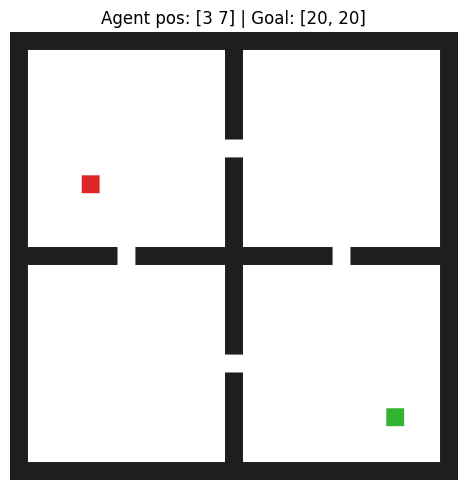

In [7]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# --- paste your class definitions above this line ---

env_base = FourRoomsGridWorld(render_mode="rgb_array")
env = FourRoomsGoalWrapper(env_base, goal_position=(20, 20))

obs, info = env.reset()
print("Start obs:", obs, "| Goal:", info["goal_position"])

sxx = env_base.sample_initial_state()
print("Sampled initial state:", sxx)

frames = []
for _ in range(200):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()
    frames.append(frame)
    if terminated or truncated:
        break

# --- render a single static frame ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(frames[-1])
ax.set_title(f"Agent pos: {obs.astype(int)} | Goal: {info['goal_position']}")
ax.axis("off")
plt.tight_layout()

In [ ]:
# Rewrite version
# ── Imports for live visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ── Hyperparameters ────────────────────────────────────────────────────────────
TOTAL_ENV_STEPS    = 100000   # total environment steps to collect
WARMUP_STEPS       = 10000    # random-action steps before any policy learning
BATCH_SIZE         = 256      # critic / actor batch size
SAMPLES_PER_INSERT = 64       # paper setting: each inserted transition is reused this many times on average
LR                 = 3e-4     # learning rate for critic + actor
INIT_ALPHA         = 0.5     # initial entropy weight before automatic tuning
ALPHA_LR           = 3e-4     # learning rate for entropy-weight tuning
TARGET_ENTROPY     = 0      # paper setting so it becomes deterministic
MIN_STD            = 1e-6     # paper setting: minimum actor std
SLIP_PROB          = 0.0     # slight transition stochasticity for learning robustness
LOG_INTERVAL       = 50       # refresh / print every this many gradient-update steps
MAX_HORIZON        = 800
NUMBER_OF_SGD_UPDATES_PER_STEP = 20
BUFFER_CAPACITY    = 30000
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

s_star = torch.tensor([20.0, 20.0], device=DEVICE, dtype=torch.float32)
s_star_batch = s_star.unsqueeze(0)
grad_step = 0

base_env = FourRoomsGridWorld(room_size=11, max_episode_steps=MAX_HORIZON)
env_train = FourRoomsGoalWrapper(
    base_env,
    goal_position=(20, 20),
    goal_reward=1.0,
    step_reward=0.0,
    slip_prob=SLIP_PROB,
)

obs_dim    = env_train.observation_space.shape[0]
action_dim = env_train.action_space.shape[0]

replay_buffer = TrajectoryReplayBuffer(
    capacity=BUFFER_CAPACITY,
    obs_dim=obs_dim,
    action_dim=action_dim,
    device=DEVICE,
)
print(DEVICE)

phi_model = StateActionRepresentationModel(obs_dim, action_dim, hidden_dim=256, output_dim=64, inner_layers=2, normalise=False).to(DEVICE)
psi_model = GoalRepresentationModel(obs_dim, hidden_dim=256, output_dim=64, inner_layers=2, normalise=False).to(DEVICE)
actor     = GoalConditionedActor(obs_dim, action_dim, hidden_dim=256, inner_layers=2).to(DEVICE)

target_phi_model = copy.deepcopy(phi_model).to(DEVICE).eval() # for evaluation
target_psi_model = copy.deepcopy(psi_model).to(DEVICE).eval() # for evaluation

critic_optimizer = optim.Adam(list(phi_model.parameters()) + list(psi_model.parameters()), lr=LR)
actor_optimizer  = optim.Adam(actor.parameters(), lr=LR)

# only turn on the entropy term when it is a pixel image task, based on the CRL paper
log_alpha        = torch.tensor(np.log(INIT_ALPHA), dtype=torch.float32, device=DEVICE, requires_grad=True)
alpha_optimizer  = optim.Adam([log_alpha], lr=ALPHA_LR)

# ── History buffers for visualisation ─────────────────────────────────────────
critic_loss_history     = []
actor_loss_history      = []
alpha_loss_history      = []
alpha_history           = []
ep_len_history          = []
entropy_history         = []
log_prob_history        = []
env_steps_at_update     = []
goal_similarity_history = []

def gradient_step_schedule(total_steps, warmup_steps=WARMUP_STEPS, min_utd=5, max_utd=NUMBER_OF_SGD_UPDATES_PER_STEP):

    if total_steps < warmup_steps:
        return min_utd

    ramp_progress = min((total_steps - warmup_steps) / 20_000, 1.0)
    return int(min_utd + ramp_progress * (max_utd - min_utd))


# ── Helper: collect one episode into a dict ────────────────────────────────────
def collect_episode(env, policy_fn):
    """Run one episode. policy_fn(obs_tensor) -> action_np.
    Returns (ep_dict, ep_steps, visited_states)."""
    obs_t, _ = env.reset()
    done = False
    ep = {k: [] for k in ["obs", "actions", "rewards", "next_obs", "terminated", "truncated"]}
    visited_states = [obs_t.astype(np.float32)]
    while not done:
        action_np = policy_fn(obs_t)
        next_obs_t, reward, term, trunc, _ = env.step(action_np)
        ep["obs"].append(obs_t.astype(np.float32))
        ep["actions"].append(action_np.astype(np.float32))
        ep["rewards"].append(np.float32(reward))
        ep["next_obs"].append(next_obs_t.astype(np.float32))
        ep["terminated"].append(np.float32(term))
        ep["truncated"].append(np.float32(trunc))
        visited_states.append(next_obs_t.astype(np.float32))
        obs_t = next_obs_t
        done  = term or trunc
    return ep, len(ep["obs"]), np.asarray(visited_states, dtype=np.float32)


def update_state_visit_counter(counter, states_xy, grid_size):
    if states_xy.size == 0:
        return
    xs = np.clip(states_xy[:, 0].astype(int), 0, grid_size - 1)
    ys = np.clip(states_xy[:, 1].astype(int), 0, grid_size - 1)
    np.add.at(counter, (ys, xs), 1)


def random_policy(obs_t):
    return env_train.action_space.sample()

# ── Collect one trajectory using pi(a | s, g = s*) ───────────────────
def actor_policy(obs_t):
    obs_tensor = torch.tensor(obs_t, dtype=torch.float32, device=DEVICE).unsqueeze(0)

    with torch.no_grad():
        action, _, _ = actor.sample_action(obs_tensor, s_star_batch)
    action_np = action.squeeze(0).cpu().numpy()
    return action_np


total_env_steps = 0
train_env_core = env_train.unwrapped
state_visit_counter = np.zeros((train_env_core.grid_size, train_env_core.grid_size), dtype=np.int64)
print(f"Warmup: collecting {WARMUP_STEPS:,} random-action steps …")

while total_env_steps < WARMUP_STEPS:

    ep, ep_steps, visited_states = collect_episode(env_train, random_policy)
    replay_buffer.add_episode(ep)
    update_state_visit_counter(state_visit_counter, visited_states, train_env_core.grid_size)
    total_env_steps += ep_steps


print(f"Warmup done.  Buffer size: {replay_buffer.size:,} transitions  "f"({total_env_steps:,} env steps collected).")

# main training phase with actor policy
while total_env_steps < TOTAL_ENV_STEPS:


    ep, ep_steps, visited_states = collect_episode(env_train, actor_policy)
    replay_buffer.add_episode(ep)
    update_state_visit_counter(state_visit_counter, visited_states, train_env_core.grid_size)
    total_env_steps += ep_steps

    num_updates = gradient_step_schedule(total_env_steps, warmup_steps=WARMUP_STEPS, min_utd=5, max_utd=NUMBER_OF_SGD_UPDATES_PER_STEP)

    for update in range(num_updates):

        grad_step += 1

        # Pair up positive states
        batch = replay_buffer.sample_positive_future_goal_batch(BATCH_SIZE)
        obs = batch["obs"]
        actions = batch["actions"]
        s_f = batch["future_state"] # the future state via GEOM as the goal

        # Now feed the state-action pair into the phi model, and its future state into the psi model for critic update
        phi_sa = phi_model(torch.cat([obs, actions], dim=-1))
        psi_g = psi_model(s_f)

        logits = (phi_sa @ psi_g.T)

        critic_loss = contrastive_loss(logits)

        critic_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(list(phi_model.parameters()) + list(psi_model.parameters()), 10.0)
        critic_optimizer.step()


        # Actor update - uses the same obs and goals as the critic update
        goals = replay_buffer.sample_random_goals(BATCH_SIZE) # sample random goals from the buffer for actor update
        action_sampled, log_prob, _ = actor.sample_action(obs, goals) # given an observation and a goal, the actor samples an action

        phi_sa_act = phi_model(torch.cat([obs, action_sampled], dim=-1))
        psi_g_act  = psi_model(goals)
        q_value = (phi_sa_act * psi_g_act).sum(dim=-1)
        # entropy_batch = (-log_prob).mean()
        # alpha_detached = log_alpha.exp().detach()

        actor_loss = -(q_value.mean()) # omitted the entropy term after detail reading of the paper

        actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(actor.parameters(), 10.0)
        actor_optimizer.step()

        # Now alpha loss
        if total_env_steps >= WARMUP_STEPS:

            alpha = log_alpha.exp()
            alpha_loss = (-alpha * (log_prob.detach() + TARGET_ENTROPY )).mean()

            alpha_optimizer.zero_grad()
            alpha_loss.backward()
            alpha_optimizer.step()


        # ── Record metrics ────────────────────────────────────────────────
    critic_loss_history.append(critic_loss.item())
    actor_loss_history.append(actor_loss.item())
    alpha_loss_history.append(alpha_loss.item())
    alpha_history.append(alpha.item())
    ep_len_history.append(ep_steps)
    # entropy_history.append(entropy_batch.detach().mean().item())
    # log_prob_history.append(log_prob.detach().mean().item())
    env_steps_at_update.append(total_env_steps)

    # ── Live plot every LOG_INTERVAL gradient steps ───────────────────
    if grad_step % LOG_INTERVAL == 0:
        # print(f"GradStep {grad_step:>5} | env_steps: {total_env_steps:>7,} | ep_len: {ep_steps:>3} | "
        #         f"critic_loss: {critic_loss.item():.4f} | "
        #         f"actor_loss: {actor_loss.item():.4f} | alpha: {alpha.item():.6f} | goal_sim: {goal_sim:.4f}")

        clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        axes = axes.flatten()

        axes[0].plot(env_steps_at_update, critic_loss_history, color='steelblue')
        axes[0].set_title("Critic loss (contrastive)")
        axes[0].set_xlabel("Env steps")
        axes[0].set_ylabel("Loss")

        axes[1].plot(env_steps_at_update, actor_loss_history, color='darkorange')
        axes[1].set_title("Actor loss")
        axes[1].set_xlabel("Env steps")
        axes[1].set_ylabel("Loss")

        axes[2].plot(env_steps_at_update, ep_len_history, color='seagreen')
        axes[2].axhline(MAX_HORIZON, color='gray', linestyle='--', linewidth=0.8, label='max horizon')
        axes[2].set_title("Episode length")
        axes[2].set_xlabel("Env steps")
        axes[2].set_ylabel("Steps")
        axes[2].legend()

        # axes[3].plot(env_steps_at_update, goal_similarity_history, color='mediumpurple')
        # axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        # axes[3].set_title("Goal similarity")
        # axes[3].set_xlabel("Env steps")
        # axes[3].set_ylabel("Similarity")

        plt.suptitle(f"Training progress — {total_env_steps:,} / {TOTAL_ENV_STEPS:,} env steps", fontsize=12)
        plt.tight_layout()
        plt.show()

env_train.close()
print("Training complete!")
print(f"Total env steps: {total_env_steps:,} | Online gradient updates: {grad_step:,}")
print(f"Replay buffer size: {replay_buffer.stats()['size']:,}")
# print(f"Final alpha: {log_alpha.exp().item():.6f} | Final entropy: {entropy_batch.detach().mean().item():.1f}")


mps
Warmup: collecting 10,000 random-action steps …
Warmup done.  Buffer size: 10,400 transitions  (10,400 env steps collected).


NameError: name 'log_prob' is not defined

### 5. Post-training summary plots


### 5a. Diagnostic: Network I/O distributions & positive/negative batch example

In [ ]:
# ── Diagnostic: visualise network inputs, outputs, and one contrastive batch ──────
# Run this cell after training (phi_model, psi_model, replay_buffer must exist).
#
# Panel layout:
#   Row 1: distributions of raw network inputs  (state, action, goal)
#   Row 2: distributions of network outputs φ(s,a) and ψ(g)
#   Row 3: concrete single-batch example — pos logit vs neg logits distribution
#          + scatter of φ and ψ in 2-D representation space

import matplotlib.pyplot as plt
import numpy as np
import torch

_DIAG_B = 512   # batch size used for diagnostics
phi_model.eval()
psi_model.eval()

with torch.no_grad():
    # ── Sample a batch with positive future goals ─────────────────────────
    dbatch   = replay_buffer.sample_positive_future_goal_batch(_DIAG_B)
    d_obs    = dbatch["obs"]      # (B, 2)  [position, velocity]
    d_act    = dbatch["actions"]  # (B, 1)  action
    d_goals  = dbatch["future_state"]    # (B, 2)  positive future state sf+
    d_neg    = replay_buffer.sample_negative_future_goals(_DIAG_B)  # (B, 2) negatives

    # ── Network outputs ───────────────────────────────────────────────────
    d_phi    = phi_model(torch.cat([d_obs, d_act], dim=-1))  # (B, 2)
    d_psi_p  = psi_model(d_goals)    # (B, 2)  positive goal repr
    d_psi_n  = psi_model(d_neg)      # (B, 2)  negative goal repr

    # ── Logit distributions ───────────────────────────────────────────────
    pos_logits = (d_phi * d_psi_p).sum(dim=-1).cpu().numpy()      # (B,) diagonal
    neg_logits = (d_phi @ d_psi_n.T).cpu().numpy().flatten()      # (B*B,) all cross

    d_obs_np   = d_obs.cpu().numpy()
    d_act_np   = d_act.cpu().numpy()
    d_goals_np = d_goals.cpu().numpy()
    d_neg_np   = d_neg.cpu().numpy()
    d_phi_np   = d_phi.cpu().numpy()
    d_psi_p_np = d_psi_p.cpu().numpy()
    d_psi_n_np = d_psi_n.cpu().numpy()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# ── Row 0: input distributions ────────────────────────────────────────────────
axes[0, 0].hist(d_obs_np[:, 0], bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0, 0].set_title('Input φ: position (s[0])')
axes[0, 0].set_xlabel('position')

axes[0, 1].hist(d_obs_np[:, 1], bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0, 1].set_title('Input φ: velocity (s[1])')
axes[0, 1].set_xlabel('velocity')

axes[0, 2].hist(d_act_np[:, 0], bins=40, color='coral', edgecolor='white', linewidth=0.3)
axes[0, 2].set_title('Input φ: action (a[0])')
axes[0, 2].set_xlabel('action')

# ── Row 1: network output distributions ───────────────────────────────────────
axes[1, 0].hist(d_phi_np[:, 0], bins=40, color='darkorange', edgecolor='white', linewidth=0.3, label='φ dim-0', alpha=0.7)
axes[1, 0].hist(d_phi_np[:, 1], bins=40, color='gold',       edgecolor='white', linewidth=0.3, label='φ dim-1', alpha=0.7)
axes[1, 0].set_title('Output φ(s,a): both dimensions')
axes[1, 0].legend()

axes[1, 1].hist(d_psi_p_np[:, 0], bins=40, color='seagreen',    edgecolor='white', linewidth=0.3, label='ψ(sf+) dim-0', alpha=0.7)
axes[1, 1].hist(d_psi_p_np[:, 1], bins=40, color='limegreen',   edgecolor='white', linewidth=0.3, label='ψ(sf+) dim-1', alpha=0.7)
axes[1, 1].set_title('Output ψ(positive sf+): both dimensions')
axes[1, 1].legend()

axes[1, 2].hist(d_psi_n_np[:, 0], bins=40, color='mediumpurple', edgecolor='white', linewidth=0.3, label='ψ(sf-) dim-0', alpha=0.7)
axes[1, 2].hist(d_psi_n_np[:, 1], bins=40, color='plum',         edgecolor='white', linewidth=0.3, label='ψ(sf-) dim-1', alpha=0.7)
axes[1, 2].set_title('Output ψ(negative sf-): both dimensions')
axes[1, 2].legend()

# ── Row 2: logit distributions + 2-D scatter ──────────────────────────────────
axes[2, 0].hist(pos_logits, bins=40, color='seagreen',    edgecolor='white', linewidth=0.3, label=f'positive (n={len(pos_logits)})', alpha=0.8)
axes[2, 0].hist(neg_logits, bins=80, color='mediumpurple', edgecolor='white', linewidth=0.2, label=f'negative (n={len(neg_logits)})', alpha=0.5)
axes[2, 0].axvline(np.mean(pos_logits), color='darkgreen',  linestyle='--', linewidth=1.5, label=f'μ_pos={np.mean(pos_logits):.2f}')
axes[2, 0].axvline(np.mean(neg_logits), color='darkviolet', linestyle='--', linewidth=1.5, label=f'μ_neg={np.mean(neg_logits):.2f}')
axes[2, 0].set_title('Logit distributions: pos vs neg\n(gap = contrastive signal)')
axes[2, 0].set_xlabel('φ(s,a) · ψ(g)')
axes[2, 0].legend(fontsize=8)

# 2-D scatter of φ and ψ in representation space
sc_phi = axes[2, 1].scatter(d_phi_np[:, 0],   d_phi_np[:, 1],   c='darkorange',    s=8, alpha=0.5, label='φ(s,a)')
sc_psp = axes[2, 1].scatter(d_psi_p_np[:, 0], d_psi_p_np[:, 1], c='seagreen',      s=8, alpha=0.5, label='ψ(sf+)')
sc_psn = axes[2, 1].scatter(d_psi_n_np[:, 0], d_psi_n_np[:, 1], c='mediumpurple',  s=8, alpha=0.3, label='ψ(sf-)')
# Mark s* goal
with torch.no_grad():
    psi_star_np = psi_model(s_star.unsqueeze(0)).cpu().numpy()
axes[2, 1].scatter(psi_star_np[0, 0], psi_star_np[0, 1], c='red', s=120, marker='*', zorder=5, label='ψ(s*) goal')
axes[2, 1].set_title('Representation space (2-D)\nφ(s,a), ψ(sf+), ψ(sf-), ψ(s*)')
axes[2, 1].set_xlabel('dim 0')
axes[2, 1].set_ylabel('dim 1')
axes[2, 1].legend(fontsize=8)

# Positive goal (sf+) input distribution vs negative goal (sf-) input distribution
axes[2, 2].hist(d_goals_np[:, 0], bins=40, color='seagreen',    edgecolor='white', linewidth=0.3, label='sf+ position', alpha=0.7)
axes[2, 2].hist(d_neg_np[:, 0],   bins=40, color='mediumpurple', edgecolor='white', linewidth=0.3, label='sf- position', alpha=0.7)
axes[2, 2].axvline(0.45, color='red', linestyle='--', linewidth=1.5, label='goal pos=0.45')
axes[2, 2].set_title('Raw position: sf+ vs sf-\n(do positives skew toward goal?)')
axes[2, 2].set_xlabel('position')
axes[2, 2].legend(fontsize=8)

plt.suptitle(
    f'Network I/O Diagnostic  |  buffer={replay_buffer.size:,} transitions  |  '
    f'repr_dim=obs_dim={obs_dim}  |  normalise={phi_model.normalise}',
    fontsize=11
)
plt.tight_layout()
plt.show()

phi_model.train()
psi_model.train()

print(f'\nSummary statistics:')
print(f'  φ(s,a) output  — mean: {d_phi_np.mean():.3f}  std: {d_phi_np.std():.3f}  min: {d_phi_np.min():.3f}  max: {d_phi_np.max():.3f}')
print(f'  ψ(sf+)  output  — mean: {d_psi_p_np.mean():.3f}  std: {d_psi_p_np.std():.3f}  min: {d_psi_p_np.min():.3f}  max: {d_psi_p_np.max():.3f}')
print(f'  ψ(sf-)  output  — mean: {d_psi_n_np.mean():.3f}  std: {d_psi_n_np.std():.3f}  min: {d_psi_n_np.min():.3f}  max: {d_psi_n_np.max():.3f}')
print(f'  pos logits      — mean: {pos_logits.mean():.3f}  std: {pos_logits.std():.3f}')
print(f'  neg logits      — mean: {neg_logits.mean():.3f}  std: {neg_logits.std():.3f}')
print(f'  contrastive gap (μ_pos - μ_neg): {pos_logits.mean() - neg_logits.mean():.3f}  (positive = good)')


In [ ]:
# ── Post-training summary: four-panel static plot ─────────────────────────────
# Smooth a 1-D list with a simple rolling window mean to reduce noise in the curves.
def smooth(values, window=10):
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='valid')

steps_full = np.asarray(env_steps_at_update)
smooth_w   = max(1, len(steps_full) // 20) if len(steps_full) > 0 else 1

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ─ Critic loss ─
ax = axes[0, 0]
ax.plot(steps_full, critic_loss_history, color='steelblue', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(critic_loss_history, smooth_w),
        color='steelblue', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.set_title("Critic loss (contrastive, Eq. 3)")
ax.set_xlabel("Env steps")
ax.set_ylabel("Loss")
ax.legend()

# ─ Actor loss ─
ax = axes[0, 1]
ax.plot(steps_full, actor_loss_history, color='darkorange', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(actor_loss_history, smooth_w),
        color='darkorange', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.set_title("Actor loss (Eq. 4)")
ax.set_xlabel("Env steps")
ax.set_ylabel("Loss")
ax.legend()

# ─ Episode length ─
ax = axes[1, 0]
ax.plot(steps_full, goal_similarity_history, color='seagreen', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(ep_len_history, smooth_w),
        color='seagreen', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.axhline(MAX_HORIZON, color='gray', linestyle='--', linewidth=0.8, label=f'max horizon ({MAX_HORIZON})')
ax.set_title("Episode length")
ax.set_xlabel("Env steps")
ax.set_ylabel("Steps per episode")
ax.legend()
# A shorter episode that terminates (rather than truncates) means the agent reached the goal.

# ─ Policy entropy ─
# ax = axes[1, 1]
# ax.plot(steps_full, entropy_history, color='mediumpurple', alpha=0.3, linewidth=0.8, label='raw')
# ax.plot(steps_full[smooth_w - 1:], smooth(entropy_history, smooth_w),
#         color='mediumpurple', linewidth=2, label=f'smoothed (w={smooth_w})')
# ax.axhline(TARGET_ENTROPY, color='gray', linestyle='--', linewidth=0.8, label=f'target entropy ({TARGET_ENTROPY:.1f})')
# ax.set_title("Policy entropy  H(π(·|s, g))")
# ax.set_xlabel("Env steps")
# ax.set_ylabel("Entropy (nats)")
# ax.legend()
# With target entropy = 0, the policy entropy should trend downward toward zero over training.

plt.suptitle("Post-training summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### 6. State-coverage heatmap


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_state_coverage(buffer, env):
    grid_size = env.grid_size
    visit_count = np.zeros((grid_size, grid_size), dtype=np.float32)
    
    obs_np = buffer.obs[:buffer.size]
    xs = np.clip(obs_np[:, 0].astype(int), 0, grid_size - 1)
    ys = np.clip(obs_np[:, 1].astype(int), 0, grid_size - 1)
    np.add.at(visit_count, (ys, xs), 1)

    # mask walls as white
    for (x, y) in env._blocked_cells:
        visit_count[y, x] = np.nan

    plt.figure(figsize=(6, 6))
    plt.imshow(visit_count, cmap="hot", origin="upper", interpolation="nearest")
    plt.colorbar(label="Visit count")
    plt.title("State Coverage")
    plt.show()


plot_state_coverage(replay_buffer, train_env_core)

### 7. Final policy rollout — render learned behaviour


In [ ]:
from IPython.display import Image
import imageio.v2 as imageio

RENDER_EPISODES = 20
RENDER_FPS      = 8

env_render = FourRoomsGridWorld(room_size=11, render_mode="rgb_array", max_episode_steps=MAX_HORIZON)
env_render = FourRoomsGoalWrapper(
    env_render,
    goal_position=(20, 20),
    goal_reward=1.0,
    step_reward=0.0,
    slip_prob=SLIP_PROB,
)

phi_model.eval()
psi_model.eval()
actor.eval()

all_frames = []
ep_rewards = []
trajectories = []

s_star_render = s_star.unsqueeze(0)

def deterministic_action(obs_tensor, goal_tensor):
    with torch.no_grad():
        mean, _ = actor(obs_tensor, goal_tensor)
        action = torch.tanh(mean)
    return action

for ep_i in range(RENDER_EPISODES):
    obs_r, _ = env_render.reset()
    done_r = False
    ep_rew = 0.0
    trajectory = [obs_r.copy()]

    while not done_r:
        frame = env_render.render()
        all_frames.append(frame)

        obs_tensor_r = torch.tensor(obs_r, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        action_r = deterministic_action(obs_tensor_r, s_star_render)
        action_r_np = action_r.squeeze(0).cpu().numpy()
        action_r_np = np.clip(action_r_np, env_render.action_space.low, env_render.action_space.high)

        obs_r, rew_r, term_r, trunc_r, _ = env_render.step(action_r_np)
        ep_rew += rew_r
        trajectory.append(obs_r.copy())
        done_r = term_r or trunc_r

    ep_rewards.append(ep_rew)
    trajectories.append(np.asarray(trajectory, dtype=np.float32))
    reached = np.array_equal(trajectory[-1].astype(np.int32), np.array([20, 20], dtype=np.int32))
    print(f"  Rollout {ep_i+1}: {len(trajectory)-1} steps | total reward: {ep_rew:.2f} | reached goal: {reached}")

env_render.close()
phi_model.train()
psi_model.train()
actor.train()

gif_path = "/tmp/policy_rollout.gif"
imageio.mimsave(gif_path, all_frames, fps=RENDER_FPS, loop=0)
print(f"\nSaved GIF ({len(all_frames)} frames) → {gif_path}")

goal_xy = np.array([20, 20], dtype=np.int32)
successes = [np.array_equal(path[-1].astype(np.int32), goal_xy) for path in trajectories]
success_rate = np.mean(successes) if successes else 0.0
avg_return   = np.mean(ep_rewards) if ep_rewards else 0.0
std_return   = np.std(ep_rewards) if ep_rewards else 0.0

print(f"Success rate (deterministic policy): {success_rate:.2%} over {RENDER_EPISODES} episodes")
print(f"Average return: {avg_return:.2f} ± {std_return:.2f}")

Image(gif_path)


### Q table and alpha-entropy plot

In [ ]:
# ── Q-value table-style visualisation + alpha/entropy diagnostic ───────────────
import numpy as np
import matplotlib.pyplot as plt
import torch

phi_model.eval()
psi_model.eval()

obs_low  = env_train.observation_space.low.astype(np.float32)
obs_high = env_train.observation_space.high.astype(np.float32)

x_bins = np.linspace(obs_low[0], obs_high[0], 18, dtype=np.float32)
y_bins = np.linspace(obs_low[1], obs_high[1], 18, dtype=np.float32)
action_vectors = np.array([
    [1.0, 0.0],   # right
    [-1.0, 0.0],  # left
    [0.0, 1.0],   # up
    [0.0, -1.0],  # down
], dtype=np.float32)
action_names = ["right", "left", "up", "down"]

goal_embed = psi_model(s_star.unsqueeze(0)).detach()
q_best = np.zeros((len(y_bins), len(x_bins)), dtype=np.float32)
best_action_idx = np.zeros_like(q_best, dtype=np.int32)

with torch.no_grad():
    for yi, y in enumerate(y_bins):
        states_np = np.stack([x_bins, np.full_like(x_bins, y)], axis=1)
        states = torch.tensor(states_np, dtype=torch.float32, device=DEVICE)

        q_per_action = []
        for a_vec in action_vectors:
            a_batch = torch.tensor(np.repeat(a_vec[None, :], states.shape[0], axis=0), dtype=torch.float32, device=DEVICE)
            phi_sa = phi_model(torch.cat([states, a_batch], dim=-1))
            q_sa = (phi_sa * goal_embed.expand(states.shape[0], -1)).sum(dim=-1)
            q_per_action.append(q_sa.cpu().numpy())

        q_per_action = np.stack(q_per_action, axis=0)
        best_idx = np.argmax(q_per_action, axis=0)
        q_best[yi] = q_per_action[best_idx, np.arange(q_per_action.shape[1])]
        best_action_idx[yi] = best_idx

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
extent = [x_bins.min(), x_bins.max(), y_bins.min(), y_bins.max()]

im0 = axes[0].imshow(q_best, origin='lower', aspect='equal', extent=extent, cmap='viridis')
axes[0].set_title('Max Q(s,a) over 4 directional actions')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(im0, ax=axes[0], shrink=0.9, label='Q value')

im1 = axes[1].imshow(best_action_idx, origin='lower', aspect='equal', extent=extent, cmap='tab10', vmin=0, vmax=3)
axes[1].set_title('Greedy action argmax_a Q(s,a)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
cbar = fig.colorbar(im1, ax=axes[1], shrink=0.9, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(action_names)

if len(entropy_history) and len(alpha_history):
    steps = np.array(env_steps_at_update, dtype=np.float32)
    axes[2].plot(steps, entropy_history, color='mediumpurple', linewidth=1.2, label='entropy')
    ax2 = axes[2].twinx()
    ax2.plot(steps, alpha_history, color='teal', linewidth=1.2, label='alpha')
    axes[2].axhline(TARGET_ENTROPY, color='gray', linestyle='--', linewidth=0.9)
    axes[2].set_title('Entropy / alpha trajectory')
    axes[2].set_xlabel('Environment steps')
    axes[2].set_ylabel('Entropy (nats)', color='mediumpurple')
    ax2.set_ylabel('Alpha', color='teal')

    h1, l1 = axes[2].get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    axes[2].legend(h1 + h2, l1 + l2, loc='upper right')
else:
    axes[2].text(0.5, 0.5, 'No alpha/entropy history found', ha='center', va='center')
    axes[2].set_axis_off()

plt.show()


## Transfer Evaluation

In [ ]:
# Transfer evaluation with a different sparse goal location
TRANSFER_GOAL = (1, 16)
s_star_transfer = torch.tensor([float(TRANSFER_GOAL[0]), float(TRANSFER_GOAL[1])], device=DEVICE, dtype=torch.float32)


In [ ]:
from IPython.display import Image
import imageio.v2 as imageio

RENDER_EPISODES = 20
RENDER_FPS      = 8

env_render = FourRoomsGridWorld(room_size=9, render_mode="rgb_array", max_episode_steps=MAX_HORIZON)
env_render = FourRoomsGoalWrapper(
    env_render,
    goal_position=TRANSFER_GOAL,
    goal_reward=1.0,
    step_reward=0.0,
    slip_prob=SLIP_PROB,
)

s_star_transfer_render = s_star_transfer.unsqueeze(0)

phi_model.eval()
psi_model.eval()
actor.eval()

all_frames = []
ep_rewards = []
trajectories = []

def deterministic_action(obs_tensor, goal_tensor):
    with torch.no_grad():
        mean, _ = actor(obs_tensor, goal_tensor)
        action = torch.tanh(mean)
    return action

for ep_i in range(RENDER_EPISODES):
    obs_r, _ = env_render.reset()
    done_r = False
    ep_rew = 0.0
    trajectory = [obs_r.copy()]

    while not done_r:
        frame = env_render.render()
        all_frames.append(frame)

        obs_tensor_r = torch.tensor(obs_r, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        action_r = deterministic_action(obs_tensor_r, s_star_transfer_render)
        action_r_np = action_r.squeeze(0).cpu().numpy()
        action_r_np = np.clip(action_r_np, env_render.action_space.low, env_render.action_space.high)

        obs_r, rew_r, term_r, trunc_r, _ = env_render.step(action_r_np)
        ep_rew += rew_r
        trajectory.append(obs_r.copy())
        done_r = term_r or trunc_r

    ep_rewards.append(ep_rew)
    trajectories.append(np.asarray(trajectory, dtype=np.float32))
    reached = np.array_equal(trajectory[-1].astype(np.int32), np.array(TRANSFER_GOAL, dtype=np.int32))
    print(f"  Rollout {ep_i+1}: {len(trajectory)-1} steps | total reward: {ep_rew:.2f} | reached goal: {reached}")

env_render.close()
phi_model.train()
psi_model.train()
actor.train()

gif_path = "/tmp/policy_rollout_transfer_goal.gif"
imageio.mimsave(gif_path, all_frames, fps=RENDER_FPS, loop=0)
print(f"\nSaved GIF ({len(all_frames)} frames) → {gif_path}")

goal_xy = np.array(TRANSFER_GOAL, dtype=np.int32)
successes = [np.array_equal(path[-1].astype(np.int32), goal_xy) for path in trajectories]
success_rate = np.mean(successes) if successes else 0.0
avg_return   = np.mean(ep_rewards) if ep_rewards else 0.0
std_return   = np.std(ep_rewards) if ep_rewards else 0.0

print(f"Success rate (deterministic policy): {success_rate:.2%} over {RENDER_EPISODES} episodes")
print(f"Average return: {avg_return:.2f} ± {std_return:.2f}")

Image(gif_path)
